# Corollary 10

Does contracting the projection radius reduce the influence of Byzantine nodes, improving generalization? 
Under which topologies (how many byzantine agents is this helpful) i.e. if there are no Byzantine agents, and if there are many, how useful is contracting projection radius in each case?

In [1]:
%load_ext autoreload
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path
from fastnanoid import generate
from datetime import datetime

In [2]:
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))
lib_path = project_root / "lib"
sys.path.insert(0, str(lib_path))        
sys.path.insert(0, str(project_root))   

In [3]:
%autoreload 2
from lib.graph_factory import GraphFactory
from lib.proj_const_estimator import ProjConstEstimator
from lib.utils import fetch_dataset, get_alphas, rng, seed
from lib.classifier import ByzClassifier
from lib.system import SystemSimulator
from lib.config import BASE_CONF, LOGFILE, NUM_NODES

In [4]:
RUN_DIR = Path().resolve()
config = BASE_CONF

In [5]:
global_dataset = fetch_dataset('MNIST')
gf = GraphFactory(config['train']['num_nodes'], config['train']['b'], seed('graph'))
proj_const_estimator = ProjConstEstimator(config, global_dataset, rng('proj-const-estimator')) 
classifier = ByzClassifier(config, global_dataset, rng('byz-classifier'))
sys_sim = SystemSimulator(config, global_dataset, rng('ml-system-sim'), LOGFILE)

In [6]:
proj_const_estimator.configure(gf,config)
proj_const = proj_const_estimator.estimate()

In [7]:
%%time
classifier.configure(gf,config, proj_const)
X_C_train, y_C_train, X_C_test, y_C_test = classifier.run_simulations()
classifier_metrics = classifier.train_and_eval(X_C_train, y_C_train, X_C_test, y_C_test)
C_opt_pt = classifier.clac_opt_operating_pt(0.7)
C_best_est, C_pre_pipe = classifier.get_params()

CPU times: user 6min 24s, sys: 7.42 s, total: 6min 31s
Wall time: 31.7 s


In [8]:
%%time
# Static Projection Radius
sim_params = {
'algorithms':['RDSGD'],
'atk_type':config['sys']['atk_type'],
'threat_model':'T3'
}

run_results = dict()
RUN_ID = generate()
run_results['timestamp'] = pd.to_datetime(datetime.now())
run_results['proj_const'] = proj_const
run_results['is_proj_rad_static'] = True

static_proj_radius = (config['alpha_init'] * proj_const) * np.ones(config['sys']['K'])
sys_sim.configure(gf, config, proj_const, C_pre_pipe, C_best_est, C_opt_pt, taus=static_proj_radius)
df1 = sys_sim.simulate(sim_params, run_results)
run_results['min_test_loss'] = df1.loc['RDSGD']['min_test_loss'].min()
run_results['max_test_loss'] = df1.loc['RDSGD']['max_test_loss'].max()
payload= sys_sim.log_results(run_results, RUN_DIR, RUN_ID)

==========RDSGD==========
[k=35] train_loss=1.6178
[k=70] train_loss=1.5965
[k=105] train_loss=1.5906
CPU times: user 14min 30s, sys: 5.99 s, total: 14min 36s
Wall time: 41.7 s


In [9]:
%%time
# Adaptive Projection Radius (default)
sim_params = {
'algorithms':['RDSGD', 'IOS', 'SCC', 'TriMean', 'CooMed'],
'atk_type':config['sys']['atk_type'],
'threat_model':'T3'
}

run_results = dict()
RUN_ID = generate()
run_results['timestamp'] = pd.to_datetime(datetime.now())
run_results['proj_const'] = proj_const
run_results['is_proj_rad_static'] = False

sys_sim.configure(gf, config, proj_const, C_pre_pipe, C_best_est, C_opt_pt)
df2 = sys_sim.simulate(sim_params, run_results)
run_results['min_test_loss'] = df2.loc['RDSGD']['min_test_loss'].min()
run_results['max_test_loss'] = df2.loc['RDSGD']['max_test_loss'].max()
payload = sys_sim.log_results(run_results, RUN_DIR, RUN_ID)

==========RDSGD==========
[k=35] train_loss=1.6706
[k=70] train_loss=1.6391
[k=105] train_loss=1.6296
===========IOS===========
[k=35] train_loss=1.6464
[k=70] train_loss=1.6362
[k=105] train_loss=1.6329
===========SCC===========
[k=35] train_loss=1.6207
[k=70] train_loss=1.6106
[k=105] train_loss=1.6087
=========TriMean=========
[k=35] train_loss=1.7049
[k=70] train_loss=1.6768
[k=105] train_loss=1.6680
==========CooMed=========
[k=35] train_loss=1.7356
[k=70] train_loss=1.7089
[k=105] train_loss=1.7003
CPU times: user 25min 39s, sys: 6.11 s, total: 25min 45s
Wall time: 1min 12s


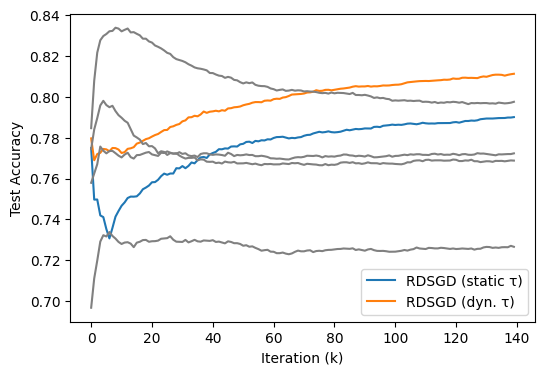

In [12]:
fig, ax = plt.subplots(1,1, figsize=(6,4))
iter_idx = np.arange(config['sys']['K'])

ax.plot(iter_idx, df1.loc['RDSGD']['test_acc'], label='RDSGD (static τ)')
ax.plot(iter_idx, df2.loc['RDSGD']['test_acc'], label='RDSGD (dyn. τ)')
for alg in ['IOS', 'SCC', 'TriMean', 'CooMed']:
    ax.plot(iter_idx, df2.loc[alg]['test_acc'], color='gray')
    

ax.set_xlabel('Iteration (k)')
ax.set_ylabel('Test Accuracy')
ax.legend(loc='lower right')
plt.show()

In [13]:
images_dir = project_root / RUN_DIR / "images"
images_dir.mkdir(parents=True, exist_ok=True)
full_path = images_dir / "results.png"
fig.savefig(full_path, bbox_inches='tight', dpi=300)